In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("C:/Users/sri krishna/Downloads/forest_cover_classification/forest_cover_data.csv")
print(df.head())

   Elevation  Aspect  Slope  Horizontal_Distance_To_Hydrology  \
0       2596      51      3                               258   
1       2590      56      2                               212   
2       2804     139      9                               268   
3       2785     155     18                               242   
4       2595      45      2                               153   

   Vertical_Distance_To_Hydrology  Horizontal_Distance_To_Roadways  \
0                               0                              510   
1                              -6                              390   
2                              65                             3180   
3                             118                             3090   
4                              -1                              391   

   Hillshade_9am  Hillshade_Noon  Hillshade_3pm  \
0            221             232            148   
1            220             235            151   
2            234             238   

In [2]:
df.shape

(581012, 55)

In [3]:
df.columns

Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area1',
       'Wilderness_Area2', 'Wilderness_Area3', 'Wilderness_Area4',
       'Soil_Type1', 'Soil_Type2', 'Soil_Type3', 'Soil_Type4', 'Soil_Type5',
       'Soil_Type6', 'Soil_Type7', 'Soil_Type8', 'Soil_Type9', 'Soil_Type10',
       'Soil_Type11', 'Soil_Type12', 'Soil_Type13', 'Soil_Type14',
       'Soil_Type15', 'Soil_Type16', 'Soil_Type17', 'Soil_Type18',
       'Soil_Type19', 'Soil_Type20', 'Soil_Type21', 'Soil_Type22',
       'Soil_Type23', 'Soil_Type24', 'Soil_Type25', 'Soil_Type26',
       'Soil_Type27', 'Soil_Type28', 'Soil_Type29', 'Soil_Type30',
       'Soil_Type31', 'Soil_Type32', 'Soil_Type33', 'Soil_Type34',
       'Soil_Type35', 'Soil_Type36', 'Soil_Type37', 'Soil_Type38',
       'Soil_Type39', 'Soil_Type40

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 55 columns):
 #   Column                              Non-Null Count   Dtype
---  ------                              --------------   -----
 0   Elevation                           581012 non-null  int64
 1   Aspect                              581012 non-null  int64
 2   Slope                               581012 non-null  int64
 3   Horizontal_Distance_To_Hydrology    581012 non-null  int64
 4   Vertical_Distance_To_Hydrology      581012 non-null  int64
 5   Horizontal_Distance_To_Roadways     581012 non-null  int64
 6   Hillshade_9am                       581012 non-null  int64
 7   Hillshade_Noon                      581012 non-null  int64
 8   Hillshade_3pm                       581012 non-null  int64
 9   Horizontal_Distance_To_Fire_Points  581012 non-null  int64
 10  Wilderness_Area1                    581012 non-null  int64
 11  Wilderness_Area2                    581012 non-null 

In [5]:
df.isnull().sum()

Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Wilderness_Area1                      0
Wilderness_Area2                      0
Wilderness_Area3                      0
Wilderness_Area4                      0
Soil_Type1                            0
Soil_Type2                            0
Soil_Type3                            0
Soil_Type4                            0
Soil_Type5                            0
Soil_Type6                            0
Soil_Type7                            0
Soil_Type8                            0
Soil_Type9                            0
Soil_Type10                           0
Soil_Type11                           0


In [6]:
df['class'].value_counts()

class
2    283301
1    211840
3     35754
7     20510
6     17367
5      9493
4      2747
Name: count, dtype: int64

In [7]:
X = df.drop('class', axis=1)
y = df['class'] -1

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print("Training size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)

Training size: (406708, 54)
Validation size: (87152, 54)
Test size: (87152, 54)


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [12]:
import tensorflow 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, InputLayer, Dropout
from tensorflow.keras.optimizers import Adam

def design_model(features):

    model = Sequential()

    model.add(InputLayer(shape=(features.shape[1],)))

    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.3))

    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.3))

    model.add(Dense(64, activation='relu'))

    model.add(Dense(32, activation='relu'))

    model.add(Dense(7, activation='softmax'))

    opt = Adam(learning_rate=0.0003)

    model.compile(
        optimizer=opt,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [14]:

model = design_model(X_train)
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=128,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)

Epoch 1/40
3178/3178 ━━━━━━━━━━━━━━━━━━━━ 32s 9ms/step - accuracy: 0.7093 - loss: 0.6848 - val_accuracy: 0.7518 - val_loss: 0.5662
Epoch 2/40
3178/3178 ━━━━━━━━━━━━━━━━━━━━ 41s 9ms/step - accuracy: 0.7512 - loss: 0.5771 - val_accuracy: 0.7749 - val_loss: 0.5178
Epoch 3/40
3178/3178 ━━━━━━━━━━━━━━━━━━━━ 41s 9ms/step - accuracy: 0.7670 - loss: 0.5398 - val_accuracy: 0.7910 - val_loss: 0.4840
Epoch 4/40
3178/3178 ━━━━━━━━━━━━━━━━━━━━ 41s 9ms/step - accuracy: 0.7797 - loss: 0.5114 - val_accuracy: 0.8062 - val_loss: 0.4542
Epoch 5/40
3178/3178 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - accuracy: 0.7892 - loss: 0.4911 - val_accuracy: 0.8167 - val_loss: 0.4344
Epoch 6/40
3178/3178 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - accuracy: 0.7977 - loss: 0.4737 - val_accuracy: 0.8227 - val_loss: 0.4188
Epoch 7/40
3178/3178 ━━━━━━━━━━━━━━━━━━━━ 41s 9ms/step - accuracy: 0.8035 - loss: 0.4606 - val_accuracy: 0.8331 - val_loss: 0.3998
Epoch 8/40
3178/3178 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - accuracy: 0.8096 - loss: 0

In [15]:
model_loss, model_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", model_loss)
print("Test Accuracy:", model_accuracy)

2724/2724 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8957 - loss: 0.2639
Test Loss: 0.2639267146587372
Test Accuracy: 0.895687997341156


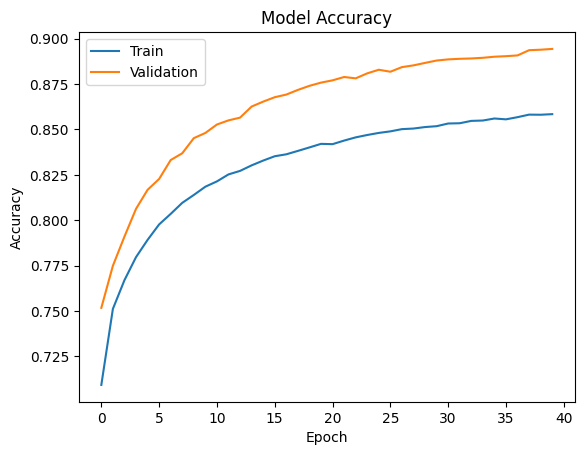

In [16]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"])

plt.show()

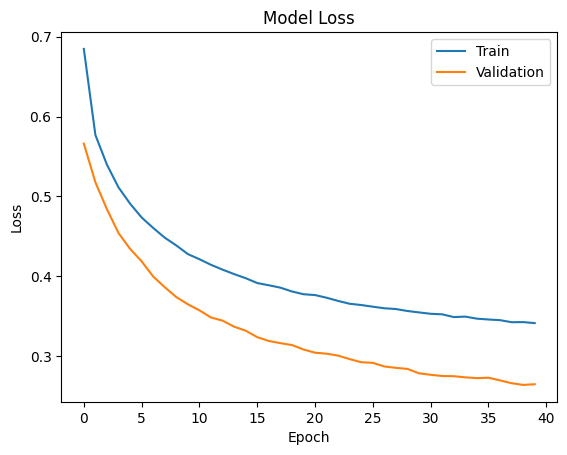

In [17]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"])

plt.show()